In [5]:
import pandas 
import numpy as np
import moments 
import dpluspy 
import scipy
import matplotlib, matplotlib.pylab as plt

matplotlib.rc("xtick", labelsize=8)
matplotlib.rc("ytick", labelsize=8)
matplotlib.rc("axes", labelsize=8)
matplotlib.rc("axes", titlesize=8)
matplotlib.rc("legend", fontsize=8)

In [6]:
# Not comprehensive: intended to extract some preliminary results
# Load best-fit models and data

u = 1.3e-8

graph0 = "fitted_models/human_neand_model_0_Bherer_yor1_rep_15.yaml"
graph1 = "fitted_models/human_neand_model_1_Bherer_yor1_rep_13.yaml"
graph2 = "fitted_models/human_neand_model_2_Bherer_yor1_rep_16.yaml"
data_file = "../../../analyses/recombination_maps/stats/subset_Bherer.pkl"

data = dpluspy.inference.load_bootstrap_reps(
    data_file, graph=graph0, return_dict=True)

model0 = dpluspy.inference.compute_bin_stats(graph0, 
    sampled_demes=data["pop_ids"], bins=data["bins"], u=u)
model1 = dpluspy.inference.compute_bin_stats(graph1, 
    sampled_demes=data["pop_ids"], bins=data["bins"], u=u)
model2 = dpluspy.inference.compute_bin_stats(graph2, 
    sampled_demes=data["pop_ids"], bins=data["bins"], u=u)


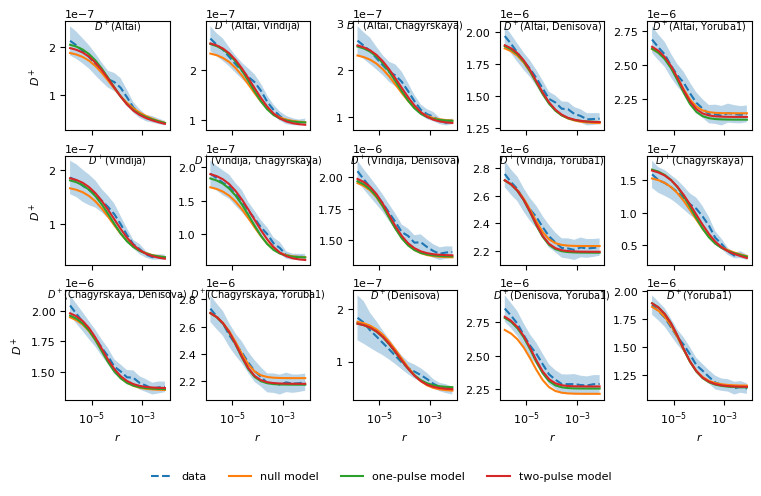

In [7]:
dpluspy.plotting.plot_D_plus_curves(
    models=[model0, model1, model2],
    pop_ids=data["pop_ids"], 
    bins=data["bins"], 
    means=data["means"], 
    varcovs=data["varcovs"], 
    ax_size=1.5,
    out="figures/models_0_1_2_summary.pdf",    
    labels=[
        "data",
        "null model",
        "one-pulse model",
        "two-pulse model"
    ]
)


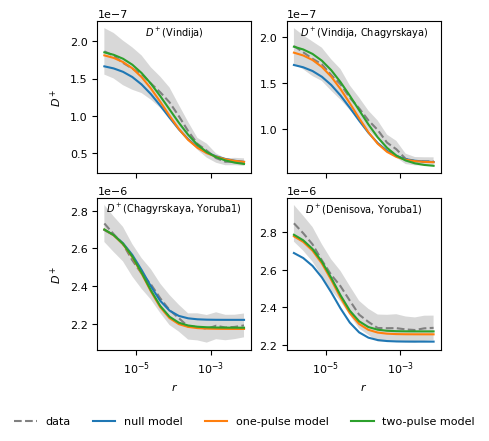

In [9]:
dpluspy.plotting.plot_D_plus_curves(
    models=[model0, model1, model2],
    pop_ids=data["pop_ids"], 
    bins=data["bins"], 
    means=data["means"], 
    varcovs=data["varcovs"], 
    stats_to_plot=[
        "D+_Vindija_Vindija", 
        "D+_Vindija_Chagyrskaya", 
        "D+_Chagyrskaya_Yoruba1", 
        "D+_Denisova_Yoruba1"
    ],
    ax_size=2,
    out="figures/human_neand_introg_models.png",
    cols=2,
    labels=[
        "data",
        "null model",
        "one-pulse model",
        "two-pulse model"
    ],
    colors=[
        "grey",
        "tab:blue",
        "tab:orange",
        "tab:green"
    ]
)
